# Caregiver Bot Analysis

This notebook is a compact, stakeholder-friendly view of the bot analysis. It keeps the focus on four things:

- clear summary tables
- simple bar charts and histograms
- plain-language decision logic
- a workbook export that matches the notebook story

The goal is readability first. Every section uses a small formula, a short example, and a simple visual so the screening logic is easy to follow without digging through the full analysis notebook.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import bot_analysis as ba

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)

project_dir = Path.cwd()
output_dir = project_dir / "Caregiver Outputs"
cache_dir = project_dir / "data_cache"

views = ba.build_stakeholder_views(output_dir, cache_dir)
stakeholder_records = views["stakeholder_records"]
workbook_action_summary = ba.build_workbook_action_summary(stakeholder_records)
workbook_key_metrics = ba.build_workbook_key_metrics(stakeholder_records)
workbook_timing_summary = ba.build_workbook_timing_summary(stakeholder_records)
workbook_issue_summary = ba.build_workbook_issue_summary(stakeholder_records)
workbook_decision_guide = ba.build_workbook_decision_guide(stakeholder_records)
workbook_workflow_summary = ba.build_workbook_workflow_summary(stakeholder_records)
study_action_summary = views["study_action_summary"]
review_signal_summary = views["review_signal_summary"]
flag_strength_summary = views["flag_strength_summary"]
print(f"Loaded {len(stakeholder_records):,} stakeholder records")

Loaded 1,956 stakeholder records


## Screening Logic, in Plain Language

The bot analysis uses a small decision tree. The formulas below are only a guide for reading the workbook and the charts.

$$\text{Survey time} = t_{fif} + t_{val} + t_{tfa} + t_{demo}$$

$$\text{Fast survey flag} = \mathbf{1}(\text{Survey time} < 11.57)$$

$$\text{Fast attitudes flag} = \mathbf{1}(t_{tfa} < 7.85)$$

$$\text{Review queue} = \text{one hard issue} \;\text{or}\; \text{two or more soft issues}$$

$$\text{Pay now} = \text{no screen trigger}$$

Small examples:

- Example 1: survey time = 12.4 minutes, attitudes time = 8.3 minutes, no other flags -> pay now.
- Example 2: survey time = 10.9 minutes, attitudes time = 7.2 minutes -> fast timing flags, so the record moves to review.
- Example 3: survey time = 13.1 minutes, but the response repeats and the family logic does not line up -> do not pay.

These examples are illustrative, not literal row-level cases. They make the screening logic easier to read before looking at the measured data.

In [2]:
from IPython.display import display

display(workbook_action_summary)
display(workbook_key_metrics)
display(workbook_timing_summary)

,Action group,Records,Share of all responses,What to do
0,Pay now,223,11.4%,Send gift card now
1,Low-risk approval,679,34.7%,Approve after quick check
2,Review,1048,53.6%,Hold for human review
3,Do not pay,6,0.3%,Do not pay


,Metric,Value,Why it matters
0,All responses reviewed,"1,956",Both studies combined.
1,Study 2 responses,"1,779",Main focus of the stakeholder bot review.
2,Need manual review or do not pay,"1,054",Highest-priority records for next-step review.
3,Broke both time limits,279,Records under both speed cutoffs.
4,Broke both time limits only,276,These 276 had no other major issue flagged.


,Action group,Study 2 records,Median full survey time,Median attitudes time
0,Pay now,70,35.54 min,23.35 min
1,Low-risk approval,660,30.23 min,19.65 min
2,Review,1043,15.25 min,8.52 min
3,Do not pay,6,9.63 min,4.40 min


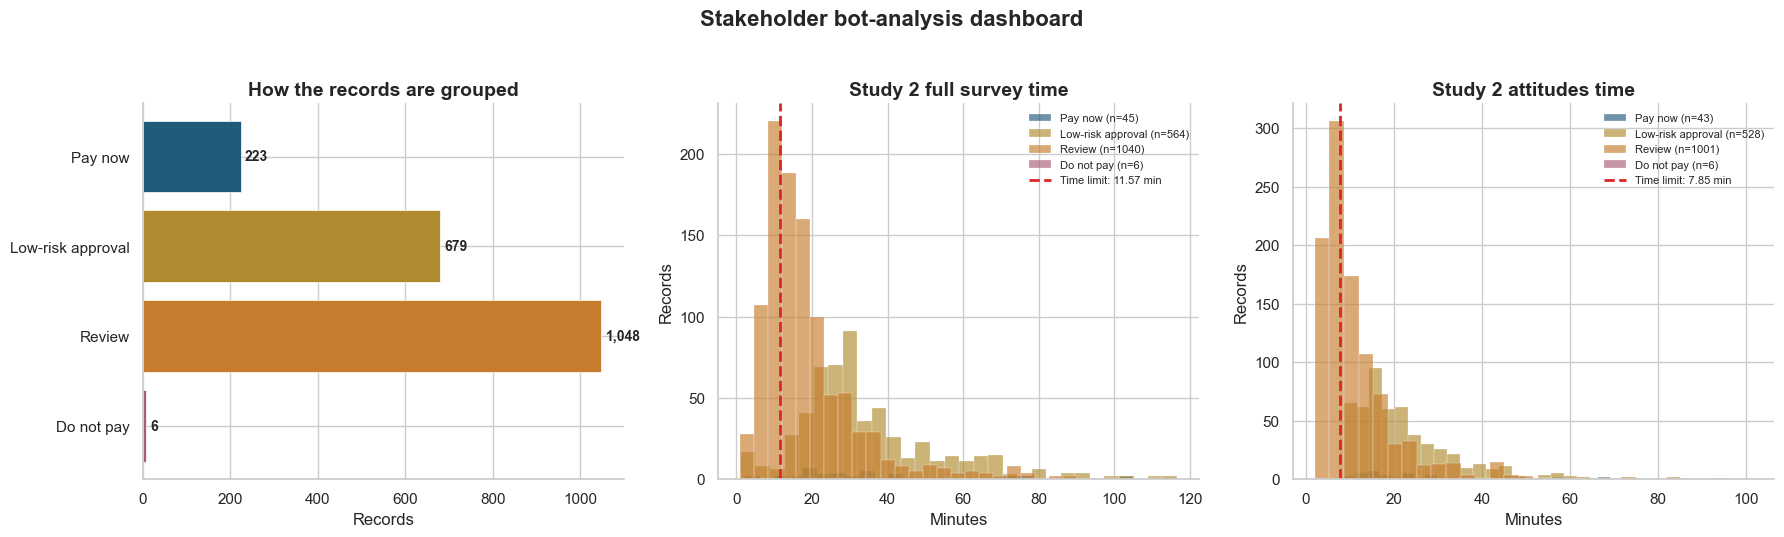

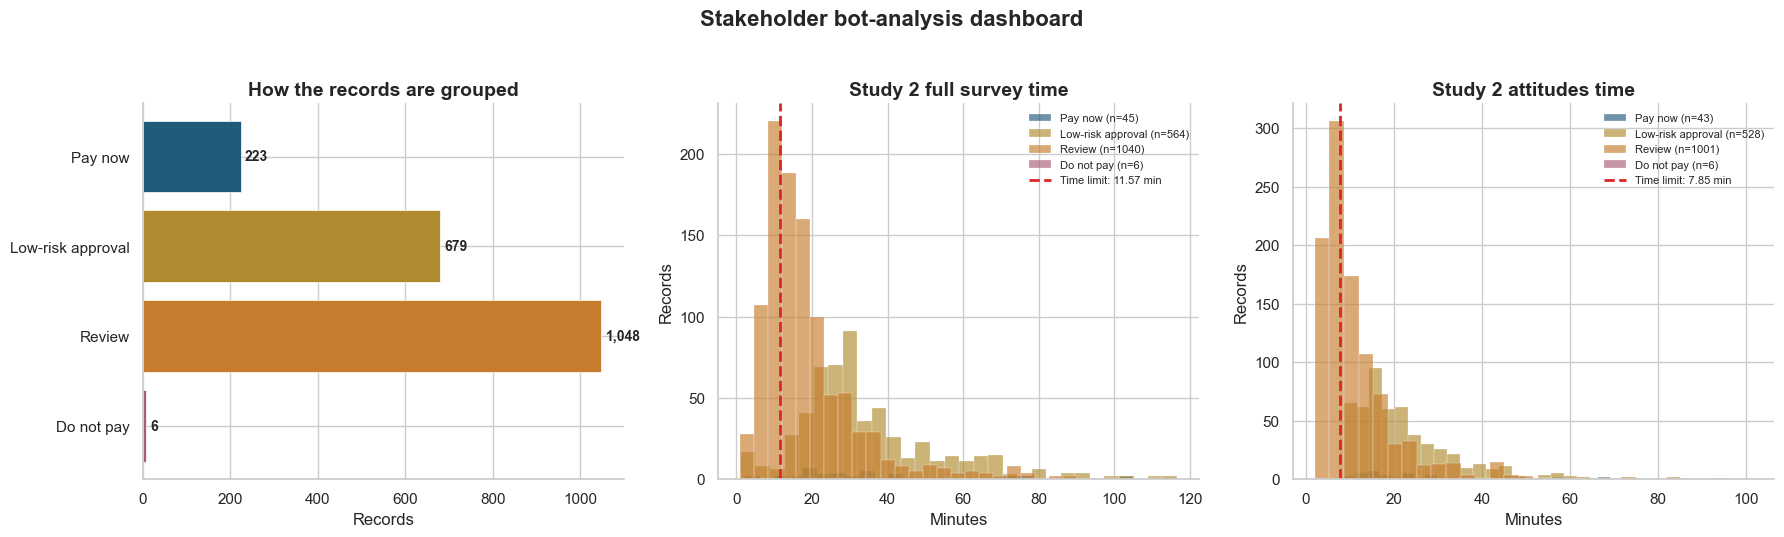

In [3]:
dashboard_fig = ba.build_workbook_dashboard_figure(stakeholder_records)
dashboard_fig

,Issue seen in Study 2,Records,Share of Study 2
0,Full survey too fast,283,15.9%
1,Attitudes section too fast,447,25.1%
2,Broke both time limits,279,15.7%
3,Bursty submissions,1676,94.2%
4,Repeated answer pattern,0,0.0%
5,Family answers did not line up,44,2.5%
6,Demographic answers did not line up,0,0.0%


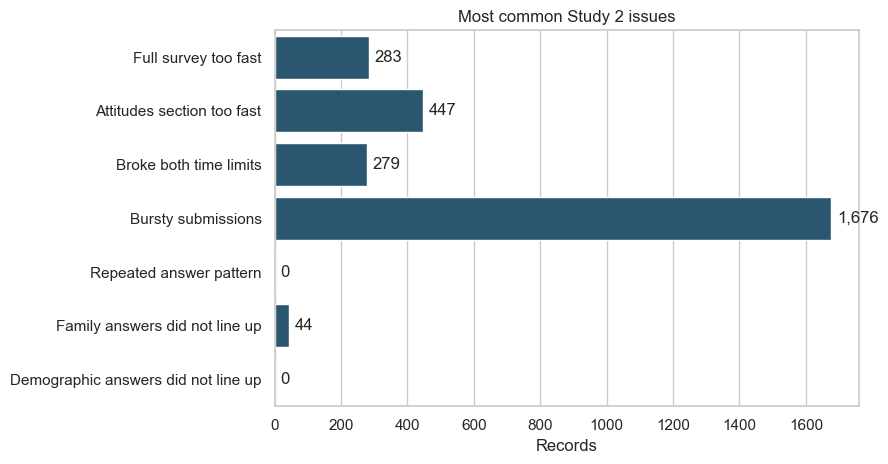

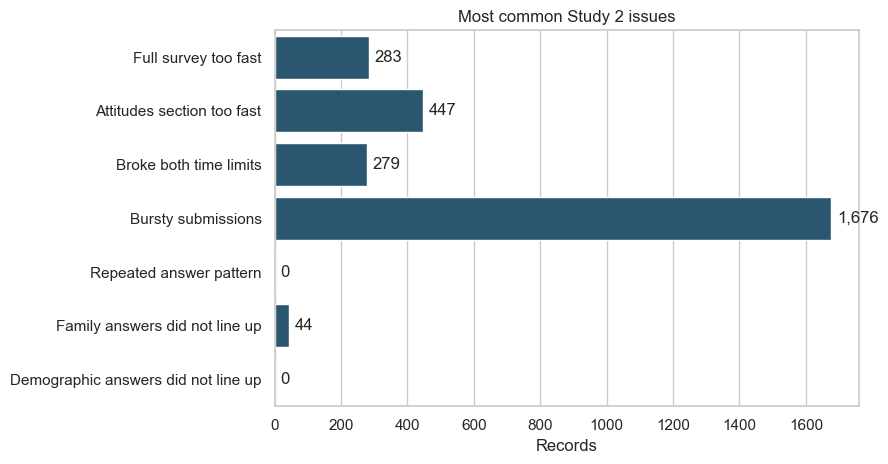

In [4]:
display(workbook_issue_summary)

fig, ax = plt.subplots(figsize=(9, 4.8))
sns.barplot(
    data=workbook_issue_summary,
    x="Records",
    y="Issue seen in Study 2",
    color="#1F5A7A",
    ax=ax,
)
ax.set_title("Most common Study 2 issues")
ax.set_xlabel("Records")
ax.set_ylabel("")
for patch in ax.patches:
    width = patch.get_width()
    ax.text(width + max(workbook_issue_summary["Records"]) * 0.01, patch.get_y() + patch.get_height() / 2, f"{int(width):,}", va="center")
fig.tight_layout()
fig

In [5]:
logic_examples = pd.DataFrame(
    [
        {
            "Example": "Clean pass",
            "Signals": "No fast timing, no repeated answer pattern, no family logic issue",
            "Result": "Pay now",
        },
        {
            "Example": "Speed concern",
            "Signals": "Survey time = 10.9 min, attitudes time = 7.2 min",
            "Result": "Review queue",
        },
        {
            "Example": "Strong invalid pattern",
            "Signals": "Repeated answers plus family logic issue",
            "Result": "Do not pay",
        },
    ]
)

display(logic_examples)

,Example,Signals,Result
0,Clean pass,"No fast timing, no repeated answer pattern, no family logic issue",Pay now
1,Speed concern,"Survey time = 10.9 min, attitudes time = 7.2 min",Review queue
2,Strong invalid pattern,Repeated answers plus family logic issue,Do not pay


## Extra Stakeholder Views

These additions keep the story simple and answer two practical questions:

- Do the two studies split into the same action groups?
- What shows up most often inside the Study 2 flagged queue?

,Study,Action group,Records,Share within study (%),What to do
0,Study 1 - Verified (4797),Pay now,153,86.4,Send gift card now
1,Study 1 - Verified (4797),Low-risk approval,19,10.7,Approve after quick check
2,Study 1 - Verified (4797),Review,5,2.8,Hold for human review
3,Study 1 - Verified (4797),Do not pay,0,0.0,Do not pay
4,Study 2 - Legacy (4581),Pay now,70,3.9,Send gift card now
5,Study 2 - Legacy (4581),Low-risk approval,660,37.1,Approve after quick check
6,Study 2 - Legacy (4581),Review,1043,58.6,Hold for human review
7,Study 2 - Legacy (4581),Do not pay,6,0.3,Do not pay


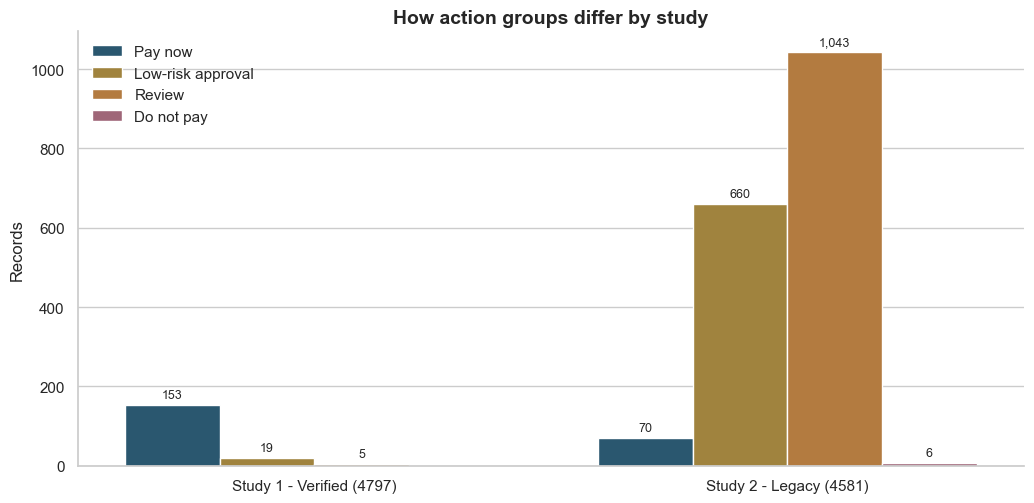

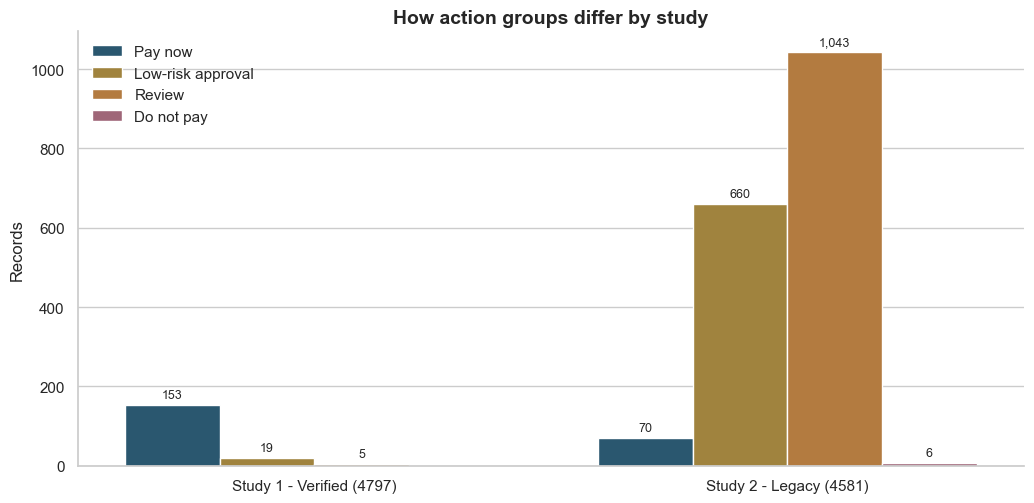

In [6]:
display(study_action_summary)

study_action_fig = ba.plot_workbook_study_action_comparison(stakeholder_records)
study_action_fig

## What Is Driving the Study 2 Review Queue

This section keeps the focus on the flagged queue only. It shows which simple signals appear most often and how many major issues each flagged record tends to carry.

,Signal in Study 2 review queue,Records,Share of review queue (%),How to read it
0,Bursty timing,1035,98.7,Common background signal; useful when it appears with other issues.
1,Attitudes section too fast,447,42.6,Shows where speed problems are most common in the questionnaire.
2,Full survey too fast,283,27.0,Signals unusually short full-survey completion.
3,Broke both timing limits,279,26.6,Stronger timing concern because both cutoffs were crossed.
4,Family logic did not line up,44,4.2,"Less common, but more substantive than timing alone."


,Flag pattern in Study 2 queue,Records,Share of review queue (%),How to read it
0,Soft-only review,560,53.4,No major issue; these records entered review because softer signals piled up.
1,One major issue,207,19.7,"One strong signal is present, but not enough for an outright rejection."
2,Two major issues,279,26.6,Two strong signals on the same record; this is the clearest review cluster.
3,Three or more major issues,3,0.3,Very concentrated concern; this is the most severe tail of the queue.


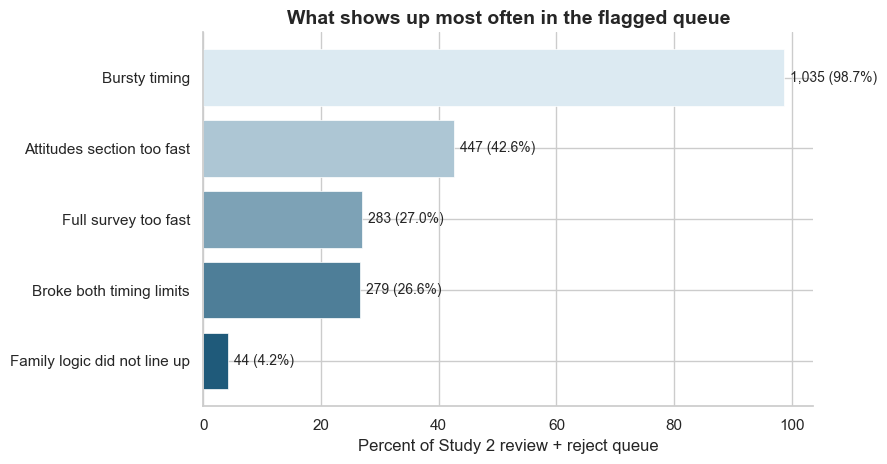

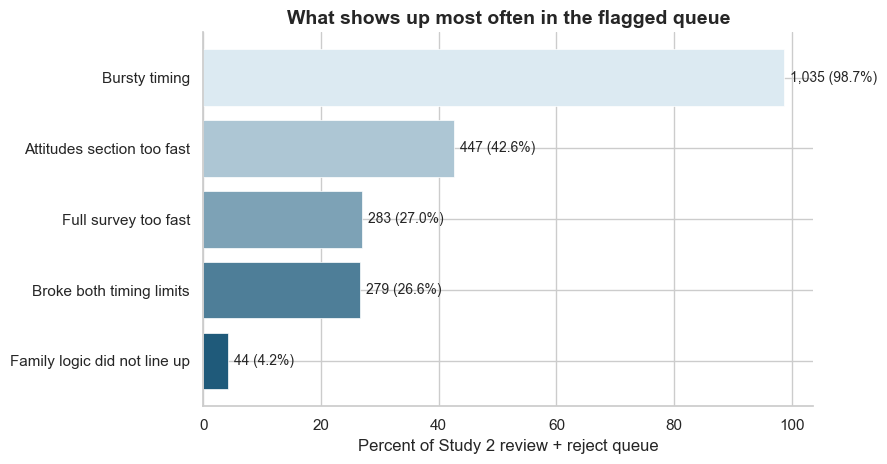

In [7]:
display(review_signal_summary)
display(flag_strength_summary)

review_signal_fig = ba.plot_workbook_review_signal_summary(stakeholder_records)
review_signal_fig

## Workbook Export

The notebook also rebuilds the stakeholder workbook so the notebook and the exported file stay aligned. The workbook is intentionally compact and uses the same plain-language labels you see above.

In [8]:
stakeholder_workbook = ba.export_stakeholder_excel(output_dir=output_dir, cache_dir=cache_dir)
print(f"Workbook written: {stakeholder_workbook.name}")
print(pd.ExcelFile(stakeholder_workbook).sheet_names)

Workbook written: ESD_Bot_Analysis_Stakeholder_Summary.xlsx
['Summary', 'Pay Now', 'Review Queue', 'Screen Guide', 'Extra Views']


### Q&A

- The most useful added stakeholder views are the study-by-study action split, the Study 2 review-queue signal mix, and the simplified timing comparison between payment-ready and flagged records.

### Data Analysis Key Findings

- Study 1 is mostly clean in this stakeholder view: 153 of 177 records (86.4%) are pay now, and only 5 (2.8%) land in review.
- Study 2 carries nearly all of the screening burden: 1,043 of 1,779 records (58.6%) land in review, 660 (37.1%) are low-risk approval, 70 (3.9%) are pay now, and 6 (0.3%) are do not pay.
- Inside the Study 2 flagged queue, bursty timing appears in 1,035 records (98.7%), attitudes-too-fast in 447 (42.6%), and both timing limits in 279 (26.6%).
- The flagged queue is not all equally severe: 560 records (53.4%) are soft-only review, 207 (19.7%) have one major issue, 279 (26.6%) have two major issues, and only 3 (0.3%) have three or more.

### Insights or Next Steps

- Keep the study split and queue-mix views in the stakeholder notebook because they explain why Study 2 needs a larger manual review effort without adding technical detail.
- Use the simplified timing comparison when presenting to non-technical reviewers; it makes the cutoff story clearer than the four-group overlay alone.